# AlexNet and DHVT on the Same Dataset

## Objective

The goal of this notebook is to compare a classical convolutional neural network, AlexNet, with a modified transformer-based model, DHVT, on the same dataset. Both models use the same dataset setting, the same validation data, and the same custom images for inference.

## Introduction

This notebook follows a complete image classification workflow. I first prepare the dataset, then train AlexNet, then train DHVT from scratch, save the best models, reload them, and finally compare their predictions on the same custom images.

The comparison is more meaningful because both models are trained and evaluated under the same data conditions.

## Why Compare AlexNet and DHVT

AlexNet is a classical CNN that uses convolution and pooling to extract local features. DHVT is a transformer-style model designed for small datasets. It combines token-based processing with inductive bias introduced by convolutional patch embedding and dynamic feed-forward design.

This comparison is useful because it contrasts a classical CNN with a transformer-style architecture trained from scratch on the same task.

## Dataset Description

This notebook supports the following dataset choices:
- `cifar10`
- `cifar100`
- `custom_folder`

The same dataset choice is shared by AlexNet and DHVT.

## 1. Import the libraries

In [1]:
import csv
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
from torch.optim import lr_scheduler
from torchvision import datasets

## 2. Choose the runtime

In [2]:
runtime_mode = 'colab'  # 'local' or 'colab'

In [3]:
if runtime_mode == 'colab':
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    project_root = Path('/content/drive/MyDrive/classification-deep-learning-project')
    data_dir = Path('/content/data')
else:
    project_root = Path.cwd()
    data_dir = project_root / 'data'

model_dir = project_root / 'models'
prediction_dir = project_root / 'predictions'
test_images_dir = project_root / 'test_images'
custom_dataset_dir = project_root / 'custom_dataset'

for folder in [data_dir, model_dir, prediction_dir, test_images_dir, custom_dataset_dir]:
    folder.mkdir(parents=True, exist_ok=True)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Runtime mode:', runtime_mode)
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Mounted at /content/drive
Runtime mode: colab
Device: cuda
GPU: Tesla T4


## 3. Choose the dataset and the common parameters

In [4]:
dataset_name = 'cifar10'  # 'cifar10', 'cifar100', or 'custom_folder'
cnn_image_size = 224
dhvt_image_size = 32
cnn_batch_size = 64
dhvt_batch_size = 128
num_epochs = 8
alexnet_learning_rate = 0.001
dhvt_learning_rate = 5e-4
weight_decay = 5e-4
num_workers = 2

## 4. Prepare the shared dataset

In [5]:
alexnet_train_transform = transforms.Compose([
    transforms.Resize((cnn_image_size, cnn_image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

alexnet_test_transform = transforms.Compose([
    transforms.Resize((cnn_image_size, cnn_image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dhvt_train_transform = transforms.Compose([
    transforms.Resize((dhvt_image_size, dhvt_image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(dhvt_image_size, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dhvt_test_transform = transforms.Compose([
    transforms.Resize((dhvt_image_size, dhvt_image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [6]:
if dataset_name == 'cifar10':
    alexnet_trainset = datasets.CIFAR10(root=str(data_dir), train=True, download=True, transform=alexnet_train_transform)
    alexnet_testset = datasets.CIFAR10(root=str(data_dir), train=False, download=True, transform=alexnet_test_transform)
    dhvt_trainset = datasets.CIFAR10(root=str(data_dir), train=True, download=True, transform=dhvt_train_transform)
    dhvt_testset = datasets.CIFAR10(root=str(data_dir), train=False, download=True, transform=dhvt_test_transform)
    classes = alexnet_trainset.classes
elif dataset_name == 'cifar100':
    alexnet_trainset = datasets.CIFAR100(root=str(data_dir), train=True, download=True, transform=alexnet_train_transform)
    alexnet_testset = datasets.CIFAR100(root=str(data_dir), train=False, download=True, transform=alexnet_test_transform)
    dhvt_trainset = datasets.CIFAR100(root=str(data_dir), train=True, download=True, transform=dhvt_train_transform)
    dhvt_testset = datasets.CIFAR100(root=str(data_dir), train=False, download=True, transform=dhvt_test_transform)
    classes = alexnet_trainset.classes
elif dataset_name == 'custom_folder':
    alexnet_trainset = datasets.ImageFolder(root=str(custom_dataset_dir / 'train'), transform=alexnet_train_transform)
    alexnet_testset = datasets.ImageFolder(root=str(custom_dataset_dir / 'val'), transform=alexnet_test_transform)
    dhvt_trainset = datasets.ImageFolder(root=str(custom_dataset_dir / 'train'), transform=dhvt_train_transform)
    dhvt_testset = datasets.ImageFolder(root=str(custom_dataset_dir / 'val'), transform=dhvt_test_transform)
    classes = alexnet_trainset.classes
else:
    raise ValueError('Unsupported dataset name.')

num_classes = len(classes)
print('Dataset:', dataset_name)
print('Number of classes:', num_classes)
print('Training samples:', len(alexnet_trainset))
print('Validation samples:', len(alexnet_testset))

100%|██████████| 170M/170M [00:04<00:00, 41.0MB/s] 


Dataset: cifar10
Number of classes: 10
Training samples: 50000
Validation samples: 10000


## 5. Train AlexNet

### AlexNet Structure

AlexNet is a convolutional neural network. In this notebook, the model contains:
- five convolutional layers,
- ReLU activations,
- local response normalization layers,
- max-pooling layers,
- one adaptive average pooling layer,
- three fully connected layers in the classifier.

The input images are resized to 224x224 so that the AlexNet-style architecture can process them correctly.

For a convolution kernel $K$ and an input feature map $X$, the output feature map $Y$ is defined by:

$$
Y_{i,j} = \sum_u \sum_v K_{u,v} X_{i+u,j+v}.
$$

After convolution, the activation function is:

$$
\mathrm{ReLU}(x) = \max(0, x).
$$

At the end of the classifier, the logits $z$ are transformed into probabilities with softmax:

$$
p_c = \frac{e^{z_c}}{\sum_{k=1}^{C} e^{z_k}}.
$$

The training objective is the cross-entropy loss:

$$
\mathcal{L} = - \sum_{c=1}^{C} y_c \log(p_c).
$$

In [7]:
alexnet_parameters = {
    'image_size': cnn_image_size,
    'batch_size': cnn_batch_size,
    'epochs': num_epochs,
    'learning_rate': alexnet_learning_rate,
    'weight_decay': weight_decay,
    'optimizer': 'AdamW',
    'scheduler': 'StepLR(step_size=4, gamma=0.1)',
    'normalization_mean': (0.5, 0.5, 0.5),
    'normalization_std': (0.5, 0.5, 0.5)
}

for key, value in alexnet_parameters.items():
    print(f'{key}: {value}')

image_size: 224
batch_size: 64
epochs: 8
learning_rate: 0.001
weight_decay: 0.0005
optimizer: AdamW
scheduler: StepLR(step_size=4, gamma=0.1)
normalization_mean: (0.5, 0.5, 0.5)
normalization_std: (0.5, 0.5, 0.5)


In [8]:
alexnet_trainloader = torch.utils.data.DataLoader(alexnet_trainset, batch_size=cnn_batch_size, shuffle=True, num_workers=num_workers)
alexnet_testloader = torch.utils.data.DataLoader(alexnet_testset, batch_size=cnn_batch_size, shuffle=False, num_workers=num_workers)

class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

alexnet_model = AlexNet(num_classes=num_classes).to(device)
alexnet_criterion = nn.CrossEntropyLoss()
alexnet_optimizer = optim.AdamW(alexnet_model.parameters(), lr=alexnet_learning_rate, weight_decay=weight_decay)
alexnet_scheduler = lr_scheduler.StepLR(alexnet_optimizer, step_size=4, gamma=0.1)

alexnet_best_model_path = model_dir / f'{dataset_name}_alexnet_best.pth'
alexnet_last_model_path = model_dir / f'{dataset_name}_alexnet_last.pth'
alexnet_best_val_accuracy = 0.0
alexnet_history = []

In [11]:
print(alexnet_model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2.0)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (cla

In [9]:
print('Start training AlexNet...')
for epoch in range(num_epochs):
    alexnet_model.train()
    running_loss = 0.0
    running_correct = 0
    total_train = 0

    for inputs, labels in alexnet_trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        alexnet_optimizer.zero_grad()
        outputs = alexnet_model(inputs)
        loss = alexnet_criterion(outputs, labels)
        loss.backward()
        alexnet_optimizer.step()
        running_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)

    alexnet_model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in alexnet_testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = alexnet_model(inputs)
            loss = alexnet_criterion(outputs, labels)
            val_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            total_val += labels.size(0)

    alexnet_scheduler.step()
    train_loss = running_loss / total_train
    train_accuracy = running_correct / total_train
    validation_loss = val_loss / total_val
    validation_accuracy = val_correct / total_val
    alexnet_history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'train_accuracy': train_accuracy, 'validation_loss': validation_loss, 'validation_accuracy': validation_accuracy})
    print(f"AlexNet Epoch {epoch + 1}/{num_epochs} | train loss: {train_loss:.4f} | train acc: {train_accuracy:.4f} | val loss: {validation_loss:.4f} | val acc: {validation_accuracy:.4f}")
    torch.save(alexnet_model.state_dict(), alexnet_last_model_path)
    if validation_accuracy > alexnet_best_val_accuracy:
        alexnet_best_val_accuracy = validation_accuracy
        torch.save(alexnet_model.state_dict(), alexnet_best_model_path)

print('AlexNet training finished.')

Start training AlexNet...
AlexNet Epoch 1/8 | train loss: 1.7893 | train acc: 0.3330 | val loss: 1.4946 | val acc: 0.4563
AlexNet Epoch 2/8 | train loss: 1.4967 | train acc: 0.4573 | val loss: 1.3651 | val acc: 0.5080
AlexNet Epoch 3/8 | train loss: 1.3956 | train acc: 0.4977 | val loss: 1.2627 | val acc: 0.5428
AlexNet Epoch 4/8 | train loss: 1.3329 | train acc: 0.5224 | val loss: 1.2237 | val acc: 0.5558
AlexNet Epoch 5/8 | train loss: 1.2026 | train acc: 0.5712 | val loss: 1.1035 | val acc: 0.6044
AlexNet Epoch 6/8 | train loss: 1.1614 | train acc: 0.5858 | val loss: 1.0841 | val acc: 0.6112
AlexNet Epoch 7/8 | train loss: 1.1463 | train acc: 0.5923 | val loss: 1.0714 | val acc: 0.6221
AlexNet Epoch 8/8 | train loss: 1.1229 | train acc: 0.5981 | val loss: 1.0584 | val acc: 0.6254
AlexNet training finished.


## 6. Define DHVT

### DHVT Structure

DHVT is a transformer-style model designed for small datasets. In this notebook, the model contains:
- a Shared Overlapped Patch Embedding (SOPE) module,
- a learnable class token,
- learnable positional embeddings,
- a stack of DHVT blocks,
- head-token based multi-head self-attention,
- a DAFF module inside each block,
- a final linear classifier.

Unlike the CNN branch, DHVT is trained from scratch and uses 32x32 images.

If the input image is written as $X \in \mathbb{R}^{B \times C \times H \times W}$, the SOPE module produces token embeddings:

$$
E \in \mathbb{R}^{B \times N \times d},
$$

where $N$ is the number of tokens and $d$ is the embedding dimension.

A learnable class token is concatenated to the patch tokens:

$$
Z_0 = [x_{cls}; E].
$$

Then positional embeddings are added:

$$
Z = Z_0 + P.
$$

Inside each DHVT block, the self-attention mechanism is computed with query, key, and value matrices. The implementation keeps a head-token style attention design so that different channel groups interact through separated attention heads:

$$
Q = ZW_Q, \quad K = ZW_K, \quad V = ZW_V,
$$

$$
\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
$$

The residual form of one DHVT block is:

$$
Z' = Z + \mathrm{MHSA}(\mathrm{LN}(Z)),
$$

$$
Z'' = Z' + \mathrm{DAFF}(\mathrm{LN}(Z')).
$$

Inside the DAFF module, the patch tokens are projected and refined by a depthwise convolution:

$$
T_1 = W_1 T, \quad T_2 = \mathrm{DWConv}(T_1), \quad T_3 = W_2 \, \mathrm{GELU}(T_2).
$$

Finally, the normalized class token is sent to the classifier head to produce the logits.

In [10]:
dhvt_parameters = {
    'image_size': dhvt_image_size,
    'batch_size': dhvt_batch_size,
    'epochs': num_epochs,
    'learning_rate': dhvt_learning_rate,
    'weight_decay': weight_decay,
    'optimizer': 'AdamW',
    'scheduler': 'CosineAnnealingLR(T_max=num_epochs)',
    'embed_dim': 192,
    'depth': 12,
    'num_heads': 4,
    'normalization_mean': (0.5, 0.5, 0.5),
    'normalization_std': (0.5, 0.5, 0.5)
}

for key, value in dhvt_parameters.items():
    print(f'{key}: {value}')

image_size: 32
batch_size: 128
epochs: 8
learning_rate: 0.0005
weight_decay: 0.0005
optimizer: AdamW
scheduler: CosineAnnealingLR(T_max=num_epochs)
embed_dim: 192
depth: 12
num_heads: 4
normalization_mean: (0.5, 0.5, 0.5)
normalization_std: (0.5, 0.5, 0.5)


In [12]:
class SOPE(nn.Module):
    def __init__(self, in_ch=3, embed_dim=192):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_ch, embed_dim // 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim // 2),
            nn.GELU(),
            nn.Conv2d(embed_dim // 2, embed_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim),
            nn.GELU(),
        )
    def forward(self, x):
        x = self.conv_layers(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x

class DAFF(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 4)
        self.dwconv = nn.Conv2d(dim * 4, dim * 4, 3, padding=1, groups=dim * 4)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(dim * 4, dim)
        self.channel_fc = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        cls_token = x[:, :1]
        patch_tokens = x[:, 1:]
        B, N, C = patch_tokens.shape
        y = self.fc1(patch_tokens)
        H = W = int(N ** 0.5)
        y = y.transpose(1, 2).reshape(B, C * 4, H, W)
        y = self.dwconv(y)
        y = y.reshape(B, C * 4, N).transpose(1, 2)
        y = self.act(y)
        y = self.fc2(y)
        w = y.mean(dim=1)
        w = self.channel_fc(w)
        cls_token = cls_token * w.unsqueeze(1)
        out = torch.cat([cls_token, y], dim=1)
        return out

class HeadTokenAttention(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        if dim % num_heads != 0:
            raise ValueError('dim must be divisible by num_heads')
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.head_embedding = nn.Parameter(torch.zeros(1, num_heads, dim))
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.last_attn = None

    def forward(self, x):
        B, N, C = x.shape
        cls_token = x[:, :1]
        patch_tokens = x[:, 1:]

        grouped_patch_tokens = patch_tokens.reshape(B, patch_tokens.shape[1], self.num_heads, self.head_dim)
        grouped_head_tokens = grouped_patch_tokens.mean(dim=1)
        head_tokens = torch.zeros(B, self.num_heads, self.num_heads, self.head_dim, device=x.device, dtype=x.dtype)
        head_index = torch.arange(self.num_heads, device=x.device)
        head_tokens[:, head_index, head_index, :] = grouped_head_tokens
        head_tokens = head_tokens.reshape(B, self.num_heads, C)
        head_tokens = head_tokens + self.head_embedding

        x_with_heads = torch.cat([cls_token, patch_tokens, head_tokens], dim=1)
        total_tokens = x_with_heads.shape[1]

        qkv = self.qkv(x_with_heads).reshape(B, total_tokens, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        self.last_attn = attn.detach()
        out = attn @ v
        out = out.transpose(1, 2).reshape(B, total_tokens, C)
        out = self.proj(out)

        updated_cls = out[:, :1] + out[:, N:].mean(dim=1, keepdim=True)
        updated_patch_tokens = out[:, 1:N]
        return torch.cat([updated_cls, updated_patch_tokens], dim=1)

class DHVTBlock(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = HeadTokenAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = DAFF(dim)
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class DHVT(nn.Module):
    def __init__(self, img_size=32, embed_dim=192, depth=12, num_heads=4, num_classes=10):
        super().__init__()
        self.patch_embed = SOPE(3, embed_dim)
        num_patches = (img_size // 4) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([DHVTBlock(embed_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        x = self.patch_embed(x)
        B = x.shape[0]
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls, x), dim=1)
        x = x + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        cls = x[:, 0]
        return self.head(cls)

In [13]:
dhvt_preview_model = DHVT(img_size=32, embed_dim=192, depth=12, num_heads=4, num_classes=num_classes)
print(dhvt_preview_model)

DHVT(
  (patch_embed): SOPE(
    (conv_layers): Sequential(
      (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(96, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
  (blocks): ModuleList(
    (0-11): 12 x DHVTBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): HeadTokenAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (proj): Linear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): DAFF(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (dwconv): Conv2d(768, 768, kernel_size=(3, 3), stride=(1,

## 7. Train DHVT from Scratch

In [14]:
dhvt_trainloader = torch.utils.data.DataLoader(dhvt_trainset, batch_size=dhvt_batch_size, shuffle=True, num_workers=num_workers)
dhvt_testloader = torch.utils.data.DataLoader(dhvt_testset, batch_size=dhvt_batch_size, shuffle=False, num_workers=num_workers)

dhvt_model = DHVT(img_size=32, embed_dim=192, depth=12, num_heads=4, num_classes=num_classes).to(device)
dhvt_criterion = nn.CrossEntropyLoss()
dhvt_optimizer = optim.AdamW(dhvt_model.parameters(), lr=dhvt_learning_rate, weight_decay=weight_decay)
dhvt_scheduler = lr_scheduler.CosineAnnealingLR(dhvt_optimizer, T_max=num_epochs)

dhvt_best_model_path = model_dir / f'{dataset_name}_dhvt_best.pth'
dhvt_last_model_path = model_dir / f'{dataset_name}_dhvt_last.pth'
dhvt_best_val_accuracy = 0.0
dhvt_history = []

print('Start training DHVT from scratch...')

for epoch in range(num_epochs):
    dhvt_model.train()
    running_loss = 0.0
    running_correct = 0
    total_train = 0

    for batch_index, (inputs, labels) in enumerate(dhvt_trainloader, start=1):
        inputs, labels = inputs.to(device), labels.to(device)
        dhvt_optimizer.zero_grad()
        outputs = dhvt_model(inputs)
        loss = dhvt_criterion(outputs, labels)
        loss.backward()
        dhvt_optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)

        if batch_index % 100 == 0:
            print(f"DHVT Epoch {epoch + 1}/{num_epochs}, Batch {batch_index}/{len(dhvt_trainloader)} | current loss: {loss.item():.4f}", flush=True)

    dhvt_model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in dhvt_testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = dhvt_model(inputs)
            loss = dhvt_criterion(outputs, labels)
            val_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            total_val += labels.size(0)

    dhvt_scheduler.step()
    train_loss = running_loss / total_train
    train_accuracy = running_correct / total_train
    validation_loss = val_loss / total_val
    validation_accuracy = val_correct / total_val
    dhvt_history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'train_accuracy': train_accuracy, 'validation_loss': validation_loss, 'validation_accuracy': validation_accuracy})
    print(f"DHVT Epoch {epoch + 1}/{num_epochs} | train loss: {train_loss:.4f} | train acc: {train_accuracy:.4f} | val loss: {validation_loss:.4f} | val acc: {validation_accuracy:.4f}", flush=True)
    torch.save(dhvt_model.state_dict(), dhvt_last_model_path)
    if validation_accuracy > dhvt_best_val_accuracy:
        dhvt_best_val_accuracy = validation_accuracy
        torch.save(dhvt_model.state_dict(), dhvt_best_model_path)

print('DHVT training finished.')
print('Best DHVT model saved at:', dhvt_best_model_path)

Start training DHVT from scratch...
DHVT Epoch 1/8, Batch 100/391 | current loss: 1.7453
DHVT Epoch 1/8, Batch 200/391 | current loss: 1.2786
DHVT Epoch 1/8, Batch 300/391 | current loss: 1.3054
DHVT Epoch 1/8 | train loss: 1.5266 | train acc: 0.4361 | val loss: 1.2009 | val acc: 0.5661
DHVT Epoch 2/8, Batch 100/391 | current loss: 0.9943
DHVT Epoch 2/8, Batch 200/391 | current loss: 1.1306
DHVT Epoch 2/8, Batch 300/391 | current loss: 0.9230
DHVT Epoch 2/8 | train loss: 1.1136 | train acc: 0.6042 | val loss: 0.9465 | val acc: 0.6680
DHVT Epoch 3/8, Batch 100/391 | current loss: 0.9253
DHVT Epoch 3/8, Batch 200/391 | current loss: 0.9357
DHVT Epoch 3/8, Batch 300/391 | current loss: 0.8331
DHVT Epoch 3/8 | train loss: 0.9224 | train acc: 0.6745 | val loss: 0.8430 | val acc: 0.7049
DHVT Epoch 4/8, Batch 100/391 | current loss: 0.8188
DHVT Epoch 4/8, Batch 200/391 | current loss: 0.9078
DHVT Epoch 4/8, Batch 300/391 | current loss: 0.8364
DHVT Epoch 4/8 | train loss: 0.7901 | train acc: 

## 8. Save the trained models

In [15]:
print('AlexNet best model:', alexnet_best_model_path)
print('AlexNet last model:', alexnet_last_model_path)
print('DHVT best model:', dhvt_best_model_path)
print('DHVT last model:', dhvt_last_model_path)

if runtime_mode == 'colab':
    print('These files are already saved in Google Drive because model_dir points to your Drive folder.')
    print('Google Drive model folder:', model_dir)
else:
    print('The files are saved locally in:', model_dir)

AlexNet best model: /content/drive/MyDrive/classification-deep-learning-project/models/cifar10_alexnet_best.pth
AlexNet last model: /content/drive/MyDrive/classification-deep-learning-project/models/cifar10_alexnet_last.pth
DHVT best model: /content/drive/MyDrive/classification-deep-learning-project/models/cifar10_dhvt_best.pth
DHVT last model: /content/drive/MyDrive/classification-deep-learning-project/models/cifar10_dhvt_last.pth
These files are already saved in Google Drive because model_dir points to your Drive folder.
Google Drive model folder: /content/drive/MyDrive/classification-deep-learning-project/models


## 9. Compare the validation curves

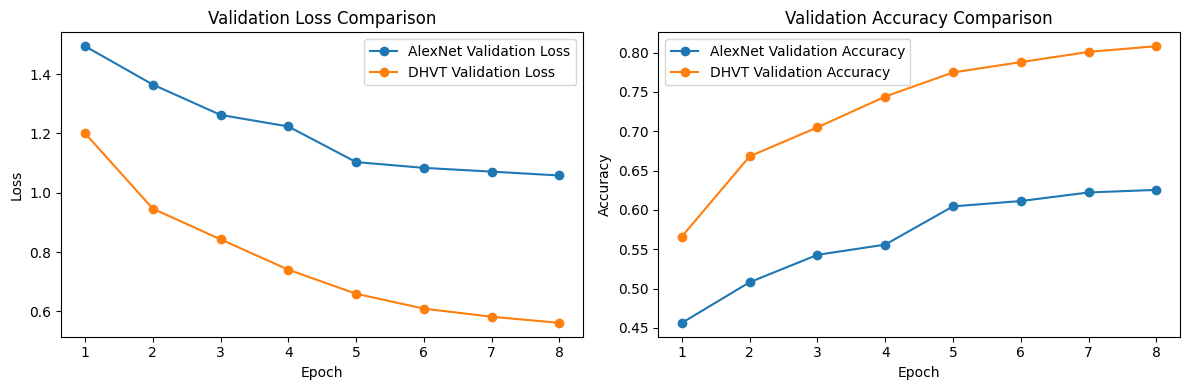

Best AlexNet validation accuracy: 0.6254
Best DHVT validation accuracy: 0.8081


In [16]:
epochs_axis = [item['epoch'] for item in alexnet_history]
alexnet_val_acc = [item['validation_accuracy'] for item in alexnet_history]
dhvt_val_acc = [item['validation_accuracy'] for item in dhvt_history]
alexnet_val_loss = [item['validation_loss'] for item in alexnet_history]
dhvt_val_loss = [item['validation_loss'] for item in dhvt_history]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_axis, alexnet_val_loss, marker='o', label='AlexNet Validation Loss')
plt.plot(epochs_axis, dhvt_val_loss, marker='o', label='DHVT Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_axis, alexnet_val_acc, marker='o', label='AlexNet Validation Accuracy')
plt.plot(epochs_axis, dhvt_val_acc, marker='o', label='DHVT Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.tight_layout()
plt.show()

print('Best AlexNet validation accuracy:', alexnet_best_val_accuracy)
print('Best DHVT validation accuracy:', dhvt_best_val_accuracy)

## 10. Predict the same custom images with both models

In [ ]:
image_paths = sorted([path for path in test_images_dir.iterdir() if path.is_file() and path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']])
print('Number of test images found:', len(image_paths))

alexnet_model = AlexNet(num_classes=num_classes).to(device)
alexnet_model.load_state_dict(torch.load(alexnet_best_model_path, map_location=device))
alexnet_model.eval()

dhvt_model = DHVT(img_size=32, embed_dim=192, depth=12, num_heads=4, num_classes=num_classes).to(device)
dhvt_model.load_state_dict(torch.load(dhvt_best_model_path, map_location=device))
dhvt_model.eval()

In [ ]:
comparison_prediction_file = prediction_dir / f'{dataset_name}_alexnet_dhvt_comparison.csv'

with comparison_prediction_file.open('w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['image_name', 'alexnet_prediction', 'alexnet_confidence', 'dhvt_prediction', 'dhvt_confidence'])

    for image_path in image_paths:
        img = Image.open(image_path).convert('RGB')
        alexnet_tensor = alexnet_test_transform(img).unsqueeze(0).to(device)
        dhvt_tensor = dhvt_test_transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            alexnet_output = alexnet_model(alexnet_tensor)
            alexnet_probabilities = torch.softmax(alexnet_output[0], dim=0)
            alexnet_confidence, alexnet_predicted = torch.max(alexnet_probabilities, 0)

            dhvt_output = dhvt_model(dhvt_tensor)
            dhvt_probabilities = torch.softmax(dhvt_output[0], dim=0)
            dhvt_confidence, dhvt_predicted = torch.max(dhvt_probabilities, 0)

        alexnet_label = classes[alexnet_predicted.item()]
        dhvt_label = classes[dhvt_predicted.item()]
        writer.writerow([image_path.name, alexnet_label, f'{alexnet_confidence.item():.6f}', dhvt_label, f'{dhvt_confidence.item():.6f}'])

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'AlexNet: {alexnet_label} ({alexnet_confidence.item() * 100:.2f}%)\nDHVT: {dhvt_label} ({dhvt_confidence.item() * 100:.2f}%)')
        plt.show()

print('Comparison predictions saved in:', comparison_prediction_file)

## 11. Confusion Matrices

In [17]:
alexnet_confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)
dhvt_confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)

alexnet_predictions_all = []
dhvt_predictions_all = []
alexnet_labels_all = []
dhvt_labels_all = []

alexnet_model.eval()
with torch.no_grad():
    for alex_inputs, labels in alexnet_testloader:
        alex_inputs, labels = alex_inputs.to(device), labels.to(device)
        alex_outputs = alexnet_model(alex_inputs)
        alex_preds = alex_outputs.argmax(dim=1)

        alexnet_predictions_all.extend(alex_preds.cpu().tolist())
        alexnet_labels_all.extend(labels.cpu().tolist())

        for true_label, alex_pred in zip(labels.cpu(), alex_preds.cpu()):
            alexnet_confusion[true_label, alex_pred] += 1

dhvt_model.eval()
with torch.no_grad():
    for dhvt_inputs, labels in dhvt_testloader:
        dhvt_inputs, labels = dhvt_inputs.to(device), labels.to(device)
        dhvt_outputs = dhvt_model(dhvt_inputs)
        dhvt_preds = dhvt_outputs.argmax(dim=1)

        dhvt_predictions_all.extend(dhvt_preds.cpu().tolist())
        dhvt_labels_all.extend(labels.cpu().tolist())

        for true_label, dhvt_pred in zip(labels.cpu(), dhvt_preds.cpu()):
            dhvt_confusion[true_label, dhvt_pred] += 1

if alexnet_labels_all != dhvt_labels_all:
    raise ValueError('The label order of AlexNet and DHVT evaluation loaders does not match.')

labels_all = alexnet_labels_all
print('Confusion matrices computed successfully with aligned evaluation labels.')

Confusion matrices computed successfully.


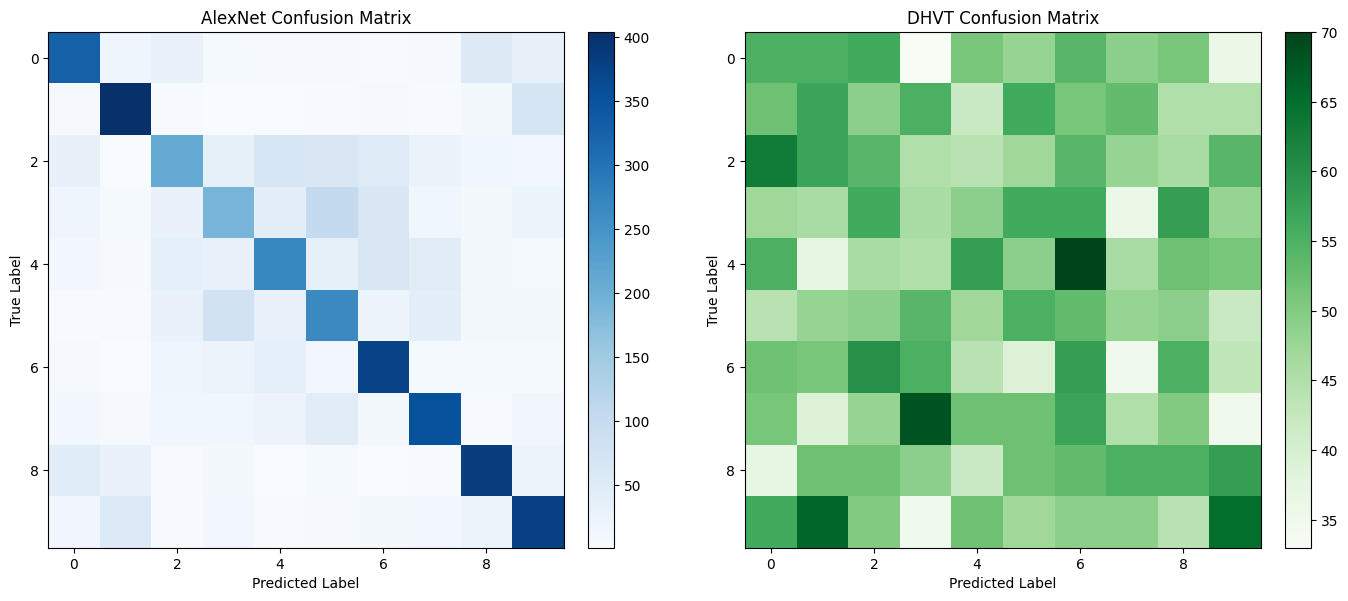

In [18]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(alexnet_confusion.numpy(), cmap='Blues')
plt.title('AlexNet Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(dhvt_confusion.numpy(), cmap='Greens')
plt.title('DHVT Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 13. Parameter Count Comparison

In [20]:
alexnet_num_params = sum(p.numel() for p in alexnet_model.parameters())
dhvt_num_params = sum(p.numel() for p in dhvt_model.parameters())

print('AlexNet number of parameters:', alexnet_num_params)
print('DHVT number of parameters:', dhvt_num_params)

AlexNet number of parameters: 58322314
DHVT number of parameters: 6504202


## 14. Misclassified Examples

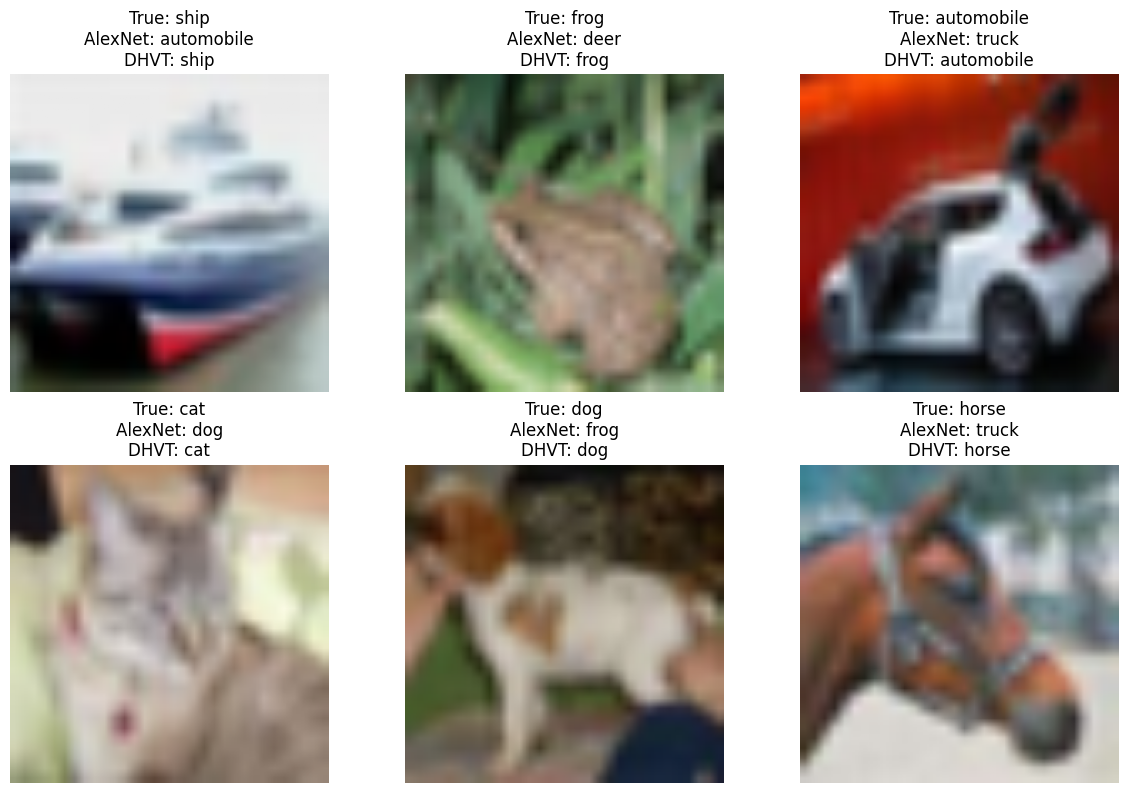

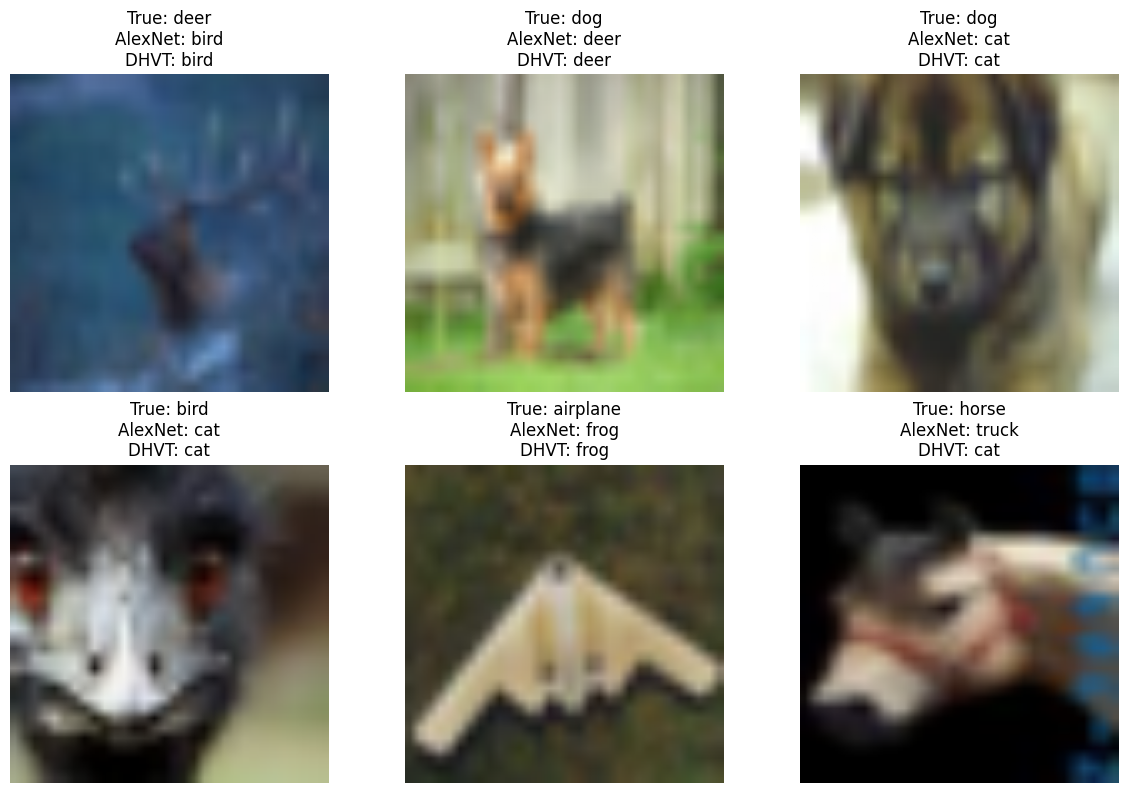

In [36]:
misclassified_examples = []
both_wrong_examples = []

alexnet_eval_for_images = datasets.CIFAR10(root=str(data_dir), train=False, download=True, transform=alexnet_test_transform) if dataset_name == 'cifar10' else None
if dataset_name == 'cifar100':
    alexnet_eval_for_images = datasets.CIFAR100(root=str(data_dir), train=False, download=True, transform=alexnet_test_transform)

if alexnet_eval_for_images is not None:
    for index in range(len(labels_all)):
        true_label = labels_all[index]
        alex_pred = alexnet_predictions_all[index]
        dhvt_pred = dhvt_predictions_all[index]
        image_tensor, _ = alexnet_eval_for_images[index]

        if alex_pred != true_label or dhvt_pred != true_label:
            misclassified_examples.append((image_tensor, true_label, alex_pred, dhvt_pred))

        if alex_pred != true_label and dhvt_pred != true_label:
            both_wrong_examples.append((image_tensor, true_label, alex_pred, dhvt_pred))

        if len(misclassified_examples) >= 6 and len(both_wrong_examples) >= 6:
            break

    plt.figure(figsize=(12, 8))
    for i, (image_tensor, true_label, alex_pred, dhvt_pred) in enumerate(misclassified_examples[:6], start=1):
        image = image_tensor.permute(1, 2, 0).numpy()
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)
        plt.subplot(2, 3, i)
        plt.imshow(image)
        plt.axis('off')
        plt.title(f'True: {classes[true_label]}\nAlexNet: {classes[alex_pred]}\nDHVT: {classes[dhvt_pred]}')

    plt.tight_layout()
    plt.show()

    if len(both_wrong_examples) > 0:
        plt.figure(figsize=(12, 8))
        for i, (image_tensor, true_label, alex_pred, dhvt_pred) in enumerate(both_wrong_examples[:6], start=1):
            image = image_tensor.permute(1, 2, 0).numpy()
            image = (image * 0.5) + 0.5
            image = np.clip(image, 0, 1)
            plt.subplot(2, 3, i)
            plt.imshow(image)
            plt.axis('off')
            plt.title(f'True: {classes[true_label]}\nAlexNet: {classes[alex_pred]}\nDHVT: {classes[dhvt_pred]}')

        plt.tight_layout()
        plt.show()
    else:
        print('No samples were misclassified by both models in the current evaluation set.')
else:
    print('Misclassified example visualization is prepared for CIFAR datasets in this notebook.')

## 15. Confidence Distribution and Error Confidence


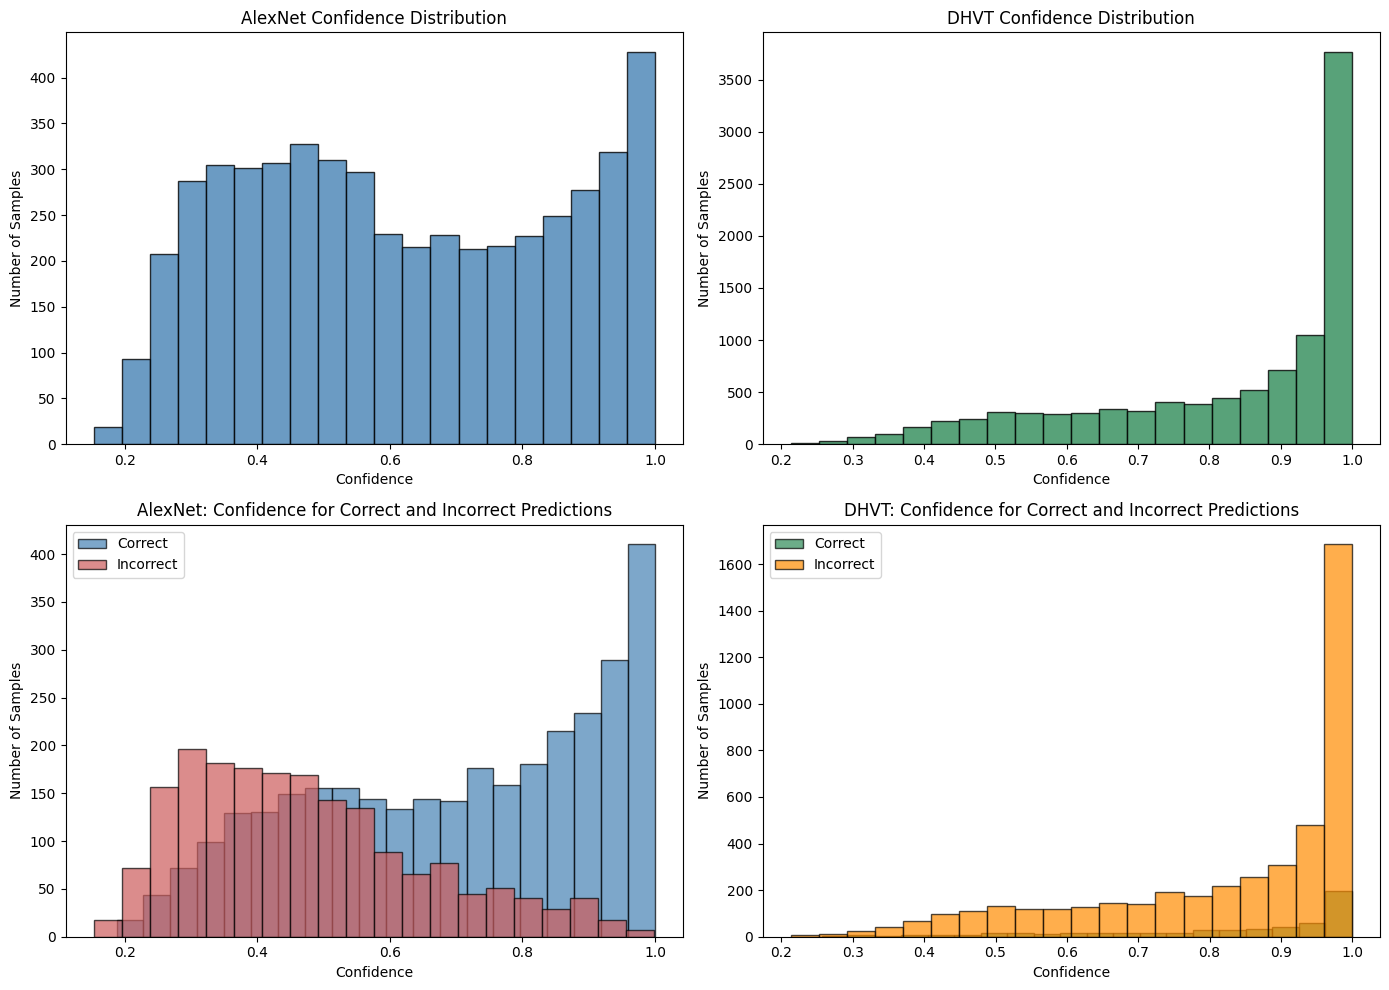

AlexNet mean confidence: 0.6150374209266628
AlexNet mean confidence on correct predictions: 0.7000459865101334
AlexNet mean confidence on incorrect predictions: 0.47118373539723274
DHVT mean confidence: 0.8247056680634618
DHVT mean confidence on correct predictions: 0.828546291448339
DHVT mean confidence on incorrect predictions: 0.8289353332578334


In [23]:
alexnet_confidences = []
dhvt_confidences = []
alexnet_correct_confidences = []
alexnet_wrong_confidences = []
dhvt_correct_confidences = []
dhvt_wrong_confidences = []

alexnet_model.eval()
with torch.no_grad():
    for alex_inputs, labels in alexnet_testloader:
        alex_inputs, labels = alex_inputs.to(device), labels.to(device)
        alex_outputs = alexnet_model(alex_inputs)
        alex_probs = torch.softmax(alex_outputs, dim=1)
        alex_conf, alex_pred = alex_probs.max(dim=1)

        alexnet_confidences.extend(alex_conf.cpu().tolist())

        for confidence, predicted, label in zip(alex_conf.cpu().tolist(), alex_pred.cpu().tolist(), labels.cpu().tolist()):
            if predicted == label:
                alexnet_correct_confidences.append(confidence)
            else:
                alexnet_wrong_confidences.append(confidence)

dhvt_model.eval()
with torch.no_grad():
    for dhvt_inputs, labels in dhvt_testloader:
        dhvt_inputs, labels = dhvt_inputs.to(device), labels.to(device)
        dhvt_outputs = dhvt_model(dhvt_inputs)
        dhvt_probs = torch.softmax(dhvt_outputs, dim=1)
        dhvt_conf, dhvt_pred = dhvt_probs.max(dim=1)

        dhvt_confidences.extend(dhvt_conf.cpu().tolist())

        for confidence, predicted, label in zip(dhvt_conf.cpu().tolist(), dhvt_pred.cpu().tolist(), labels.cpu().tolist()):
            if predicted == label:
                dhvt_correct_confidences.append(confidence)
            else:
                dhvt_wrong_confidences.append(confidence)

plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.hist(alexnet_confidences, bins=20, alpha=0.8, color='steelblue', edgecolor='black')
plt.title('AlexNet Confidence Distribution')
plt.xlabel('Confidence')
plt.ylabel('Number of Samples')

plt.subplot(2, 2, 2)
plt.hist(dhvt_confidences, bins=20, alpha=0.8, color='seagreen', edgecolor='black')
plt.title('DHVT Confidence Distribution')
plt.xlabel('Confidence')
plt.ylabel('Number of Samples')

plt.subplot(2, 2, 3)
plt.hist(alexnet_correct_confidences, bins=20, alpha=0.7, label='Correct', color='steelblue', edgecolor='black')
plt.hist(alexnet_wrong_confidences, bins=20, alpha=0.7, label='Incorrect', color='indianred', edgecolor='black')
plt.title('AlexNet: Confidence for Correct and Incorrect Predictions')
plt.xlabel('Confidence')
plt.ylabel('Number of Samples')
plt.legend()

plt.subplot(2, 2, 4)
plt.hist(dhvt_correct_confidences, bins=20, alpha=0.7, label='Correct', color='seagreen', edgecolor='black')
plt.hist(dhvt_wrong_confidences, bins=20, alpha=0.7, label='Incorrect', color='darkorange', edgecolor='black')
plt.title('DHVT: Confidence for Correct and Incorrect Predictions')
plt.xlabel('Confidence')
plt.ylabel('Number of Samples')
plt.legend()
plt.tight_layout()
plt.show()

print('AlexNet mean confidence:', float(np.mean(alexnet_confidences)))
print('AlexNet mean confidence on correct predictions:', float(np.mean(alexnet_correct_confidences)))
print('AlexNet mean confidence on incorrect predictions:', float(np.mean(alexnet_wrong_confidences)))
print('DHVT mean confidence:', float(np.mean(dhvt_confidences)))
print('DHVT mean confidence on correct predictions:', float(np.mean(dhvt_correct_confidences)))
print('DHVT mean confidence on incorrect predictions:', float(np.mean(dhvt_wrong_confidences)))


## 16. Agreement and Disagreement Analysis


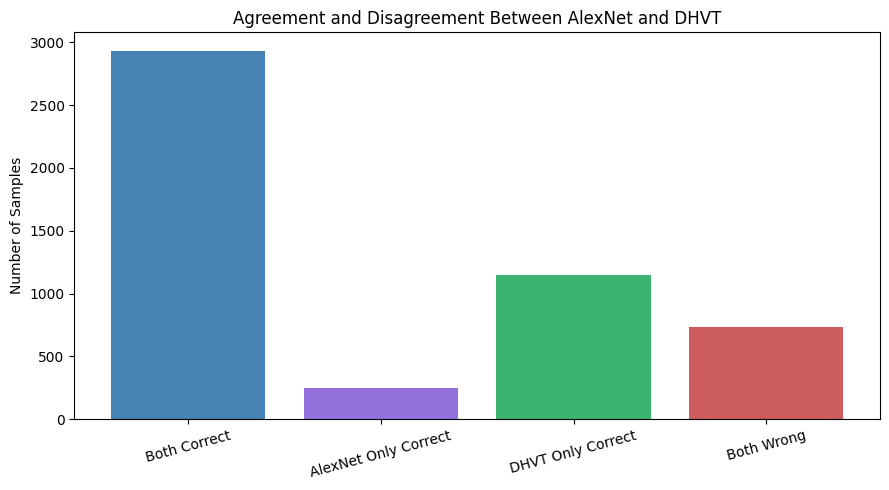

Both correct ratio: 0.5803006329113924
AlexNet only correct ratio: 0.048259493670886076
DHVT only correct ratio: 0.22646360759493672
Both wrong ratio: 0.1449762658227848


In [33]:
both_correct = 0
alexnet_only_correct = 0
dhvt_only_correct = 0
both_wrong = 0

for true_label, alex_pred, dhvt_pred in zip(labels_all, alexnet_predictions_all, dhvt_predictions_all):
    alex_correct = alex_pred == true_label
    dhvt_correct = dhvt_pred == true_label

    if alex_correct and dhvt_correct:
        both_correct += 1
    elif alex_correct and not dhvt_correct:
        alexnet_only_correct += 1
    elif not alex_correct and dhvt_correct:
        dhvt_only_correct += 1
    else:
        both_wrong += 1

agreement_labels = ['Both Correct', 'AlexNet Only Correct', 'DHVT Only Correct', 'Both Wrong']
agreement_values = [both_correct, alexnet_only_correct, dhvt_only_correct, both_wrong]
agreement_colors = ['steelblue', 'mediumpurple', 'mediumseagreen', 'indianred']

plt.figure(figsize=(9, 5))
plt.bar(agreement_labels, agreement_values, color=agreement_colors)
plt.ylabel('Number of Samples')
plt.title('Agreement and Disagreement Between AlexNet and DHVT')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

total_compared = len(labels_all)
print('Both correct ratio:', both_correct / total_compared)
print('AlexNet only correct ratio:', alexnet_only_correct / total_compared)
print('DHVT only correct ratio:', dhvt_only_correct / total_compared)
print('Both wrong ratio:', both_wrong / total_compared)


## Results and Discussion

The results in this notebook are discussed from several perspectives rather than from accuracy alone. First, the validation loss and validation accuracy curves show how the two models learn during training. AlexNet provides a classical convolutional baseline, while DHVT is expected to model broader image relationships through a transformer-style structure. By comparing the curves, it is possible to judge not only which model performs better, but also which model converges faster and which one behaves more stably across epochs.

Second, the confusion matrices provide a more detailed comparison of classification behavior. They help identify whether one model makes more systematic errors than the other and whether some categories are visually harder to separate. This is important because overall accuracy alone cannot show where the mistakes come from.

The confidence distribution plots add another layer of interpretation. They show whether the model tends to make confident predictions and whether incorrect predictions are also assigned high confidence. This is useful when discussing how trustworthy the final outputs are, not just whether they are correct.

Finally, the misclassified examples, the images misclassified by both models, and the agreement analysis are useful for qualitative evaluation. In some samples, one model may succeed while the other fails, which suggests that the two architectures learn different visual cues. In other samples, both models fail, which may indicate that the image is ambiguous, the appearance is unusual, or the classes are visually similar. These observations help explain the strengths and weaknesses of convolution-based and transformer-style approaches on the same dataset.

Overall, this comparison is not only about choosing a model with a higher score. It is also about understanding how the two model families behave, what kinds of errors they make, and whether the modified transformer model provides meaningful advantages over the classical CNN baseline.


## Conclusion

In this notebook, I compared AlexNet and DHVT on the same image classification dataset under a shared experimental setting. This design makes the comparison fairer because both models use the same training data, validation data, and custom test images.

AlexNet serves as a classical convolutional baseline, while DHVT represents a transformer-inspired model designed for small datasets. By placing the two models in one notebook, it becomes easier to compare their learning curves, confidence behavior, error cases, and agreement patterns in a direct and consistent way.

The main value of this experiment is not only to report which model performs better, but also to show how different neural network architectures respond to the same task. In conclusion, this notebook provides a complete homework-style comparison between a CNN baseline and a transformer-style model, including training, model saving, loading, inference, visual evaluation, and error analysis.


## References

1. Krizhevsky, Sutskever, and Hinton. *ImageNet Classification with Deep Convolutional Neural Networks*. 2012.
2. Lu et al. *Bridging the Gap Between Vision Transformers and Convolutional Neural Networks on Small Datasets*. 2022.
3. PyTorch Documentation. https://pytorch.org/
4. Torchvision Documentation. https://pytorch.org/vision/stable/